In [1]:
import numpy as np

from pyuvdata import UVBeam

In [2]:
fee_file = "/Users/bryna/Projects/Physics/data_files/mwa_beams/mwa_full_embedded_element_pattern.h5"

jmatrix_file = "/Users/bryna/Projects/Physics/data_files/mwa_beams/Jmatrix.fits"
zmatrix_file = "/Users/bryna/Projects/Physics/data_files/mwa_beams/Zmatrix.fits"

# delay_set = np.tile(np.arange(0, 8, 2), 4)
delay_set = np.zeros(16, dtype=int)
delays = np.empty((2, 16), dtype=int)

for pol in range(2):
    delays[pol] = delay_set


In [3]:
mwa_fee_beam = UVBeam.from_file(fee_file, delays=delays)
mwa_aee_beam = UVBeam.from_file(jmatrix_file, mwa_zfile=zmatrix_file, delays=delays)
mwa_fhd_aee_beam = UVBeam.from_file(jmatrix_file, mwa_zfile=zmatrix_file, delays=delays, mwa_include_cross_feed_coupling=False)

In [4]:
mwa_fee_beam.peak_normalize()
mwa_aee_beam.peak_normalize()
mwa_fhd_aee_beam.peak_normalize()

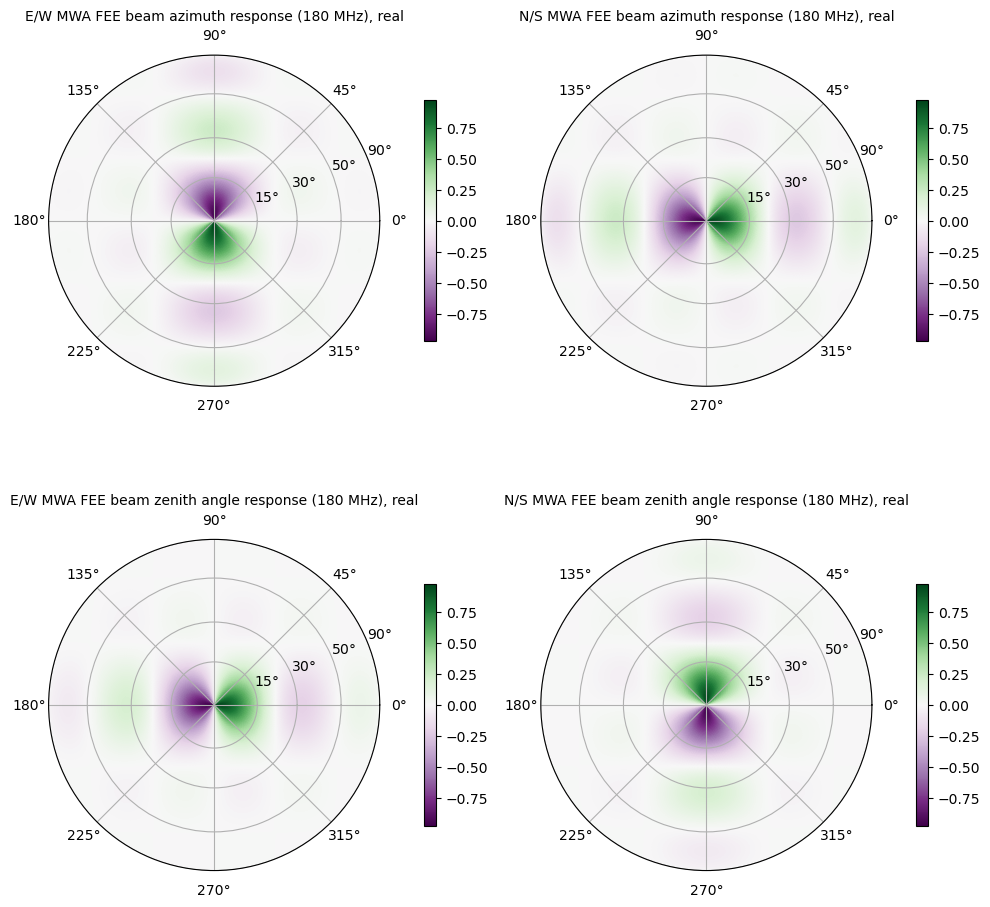

In [5]:
mwa_fee_beam.plot(freq_ind=102, beam_name="MWA FEE beam")

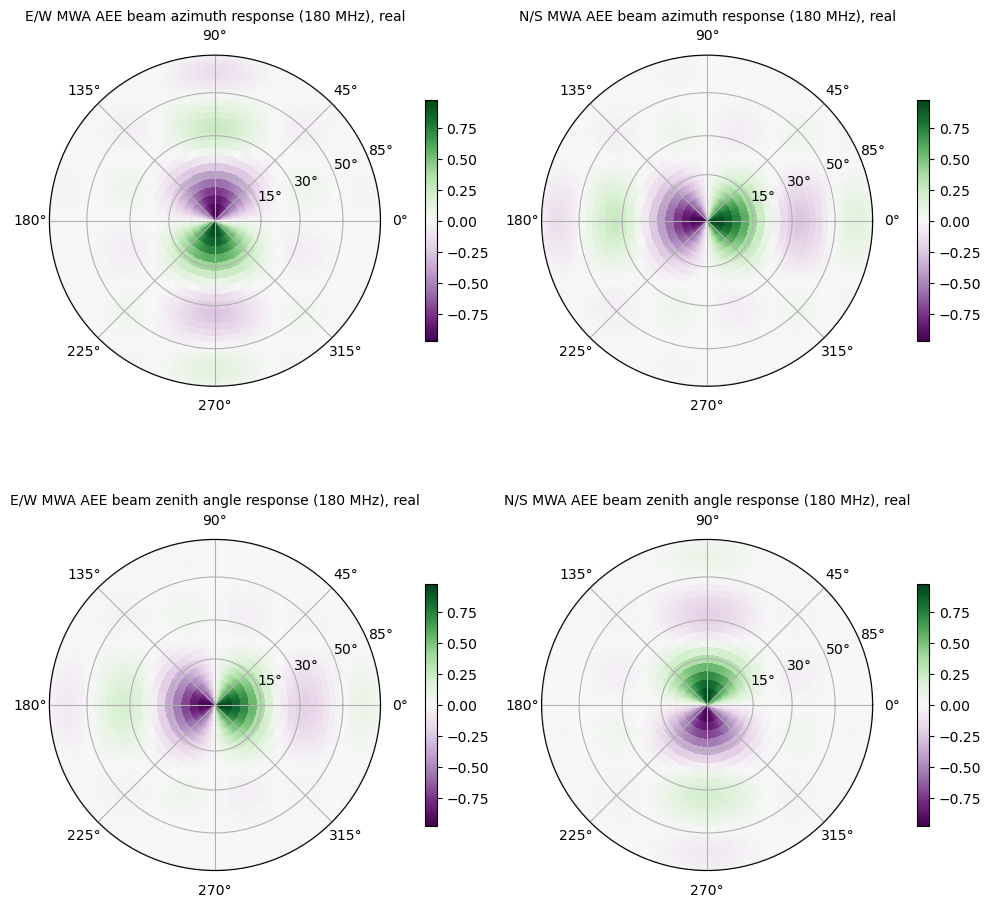

In [6]:
mwa_aee_beam.plot(freq_ind=41, beam_name="MWA AEE beam")

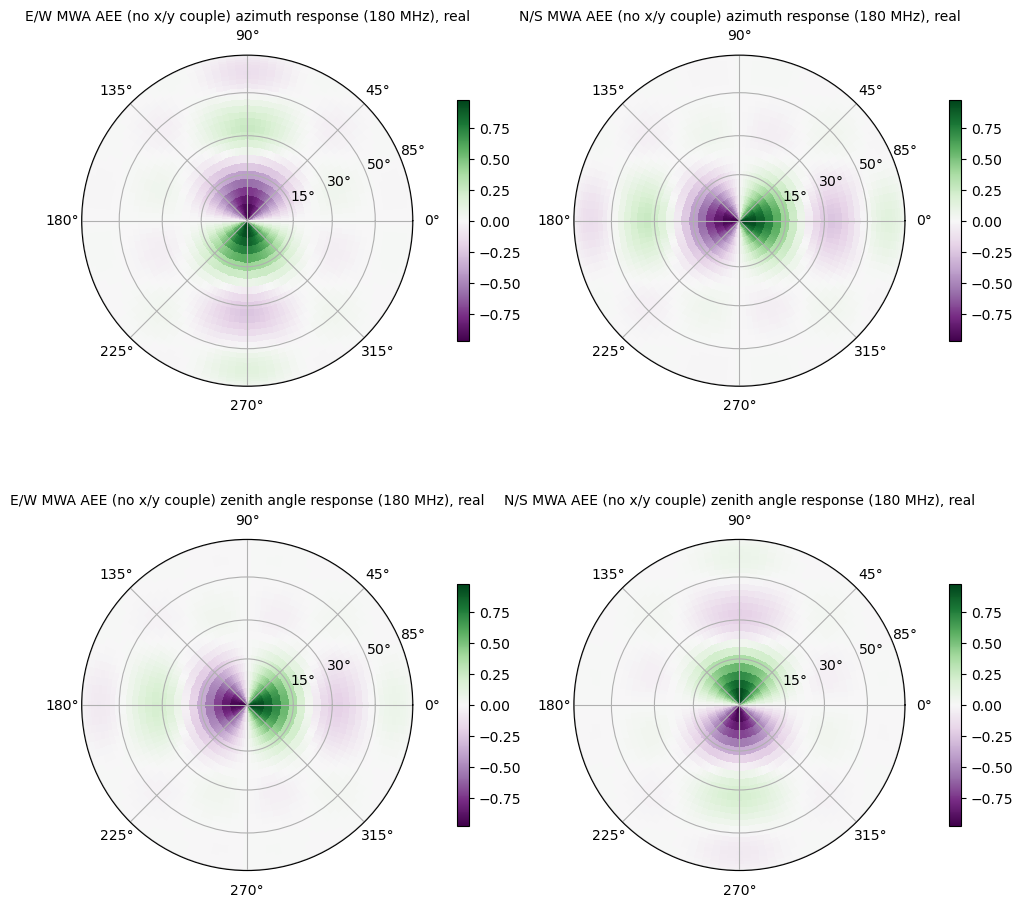

In [7]:
mwa_fhd_aee_beam.plot(freq_ind=41, beam_name="MWA AEE (no x/y couple)")

In [8]:
print(mwa_fee_beam.freq_array[102] - mwa_aee_beam.freq_array[41])
fee_at_aee_grid_beam = mwa_fee_beam.select(freq_chans=102, inplace=False)
fee_at_aee_grid_beam = fee_at_aee_grid_beam.interp(
    az_array = np.unique(mwa_aee_beam.axis1_array),
    za_array = np.unique(mwa_aee_beam.axis2_array),
    az_za_grid = True,
    new_object=True,
)

0.0


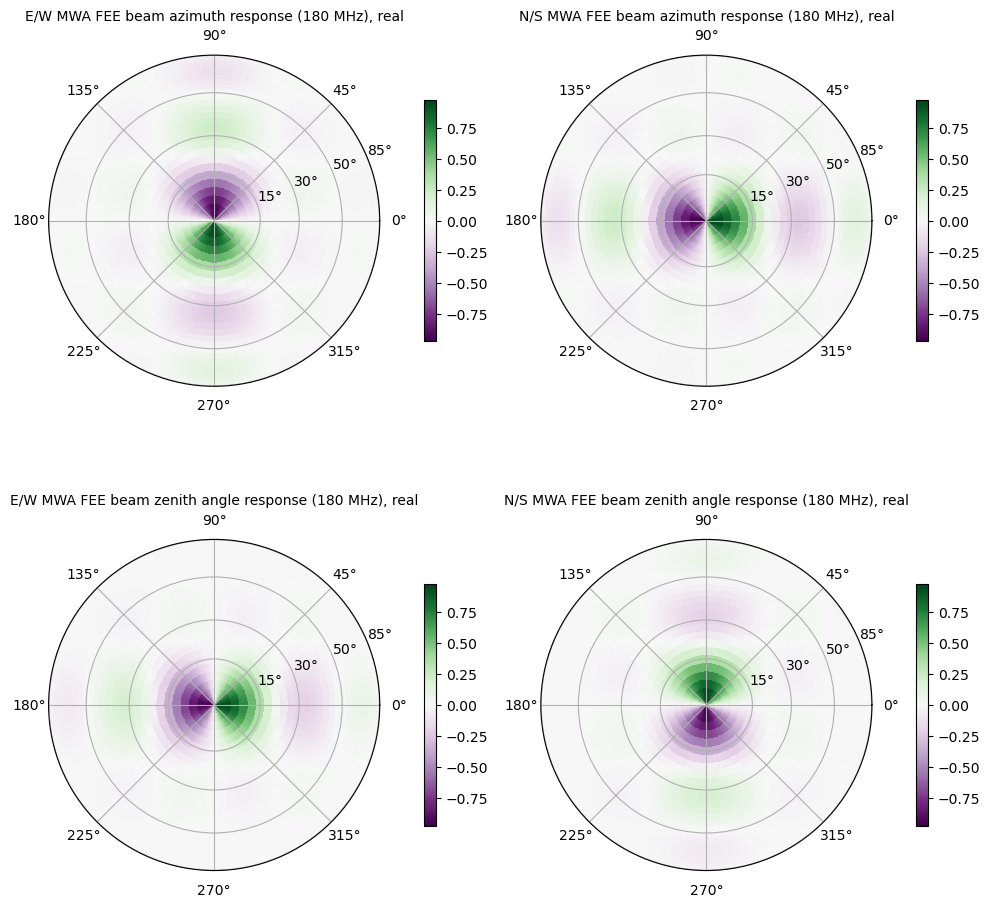

In [9]:
fee_at_aee_grid_beam.plot(freq_ind=0, beam_name="MWA FEE beam")

In [10]:
fee_aee_diff_beam = fee_at_aee_grid_beam.copy()
mwa_aee_beam_180 = mwa_aee_beam.select(freq_chans=[41], inplace=False)
fee_aee_diff_beam.data_array = fee_aee_diff_beam.data_array - mwa_aee_beam_180.data_array

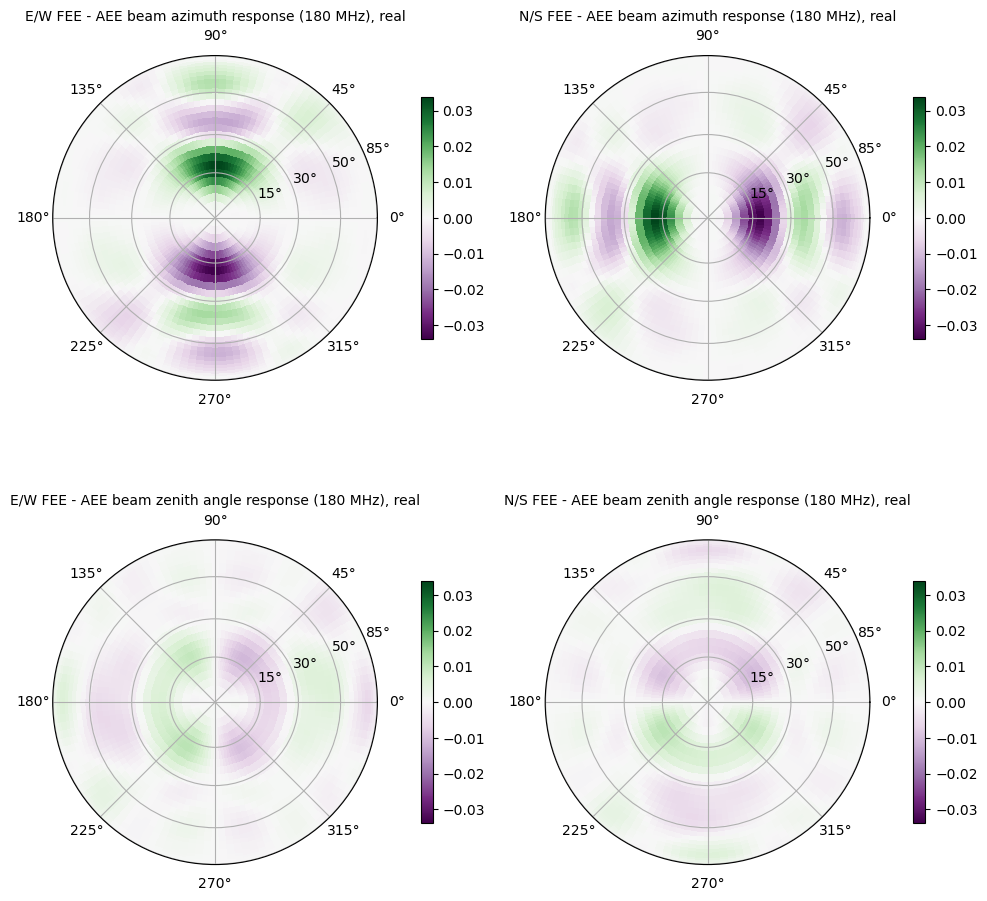

In [11]:
fee_aee_diff_beam.plot(freq_ind=0, beam_name="FEE - AEE beam")

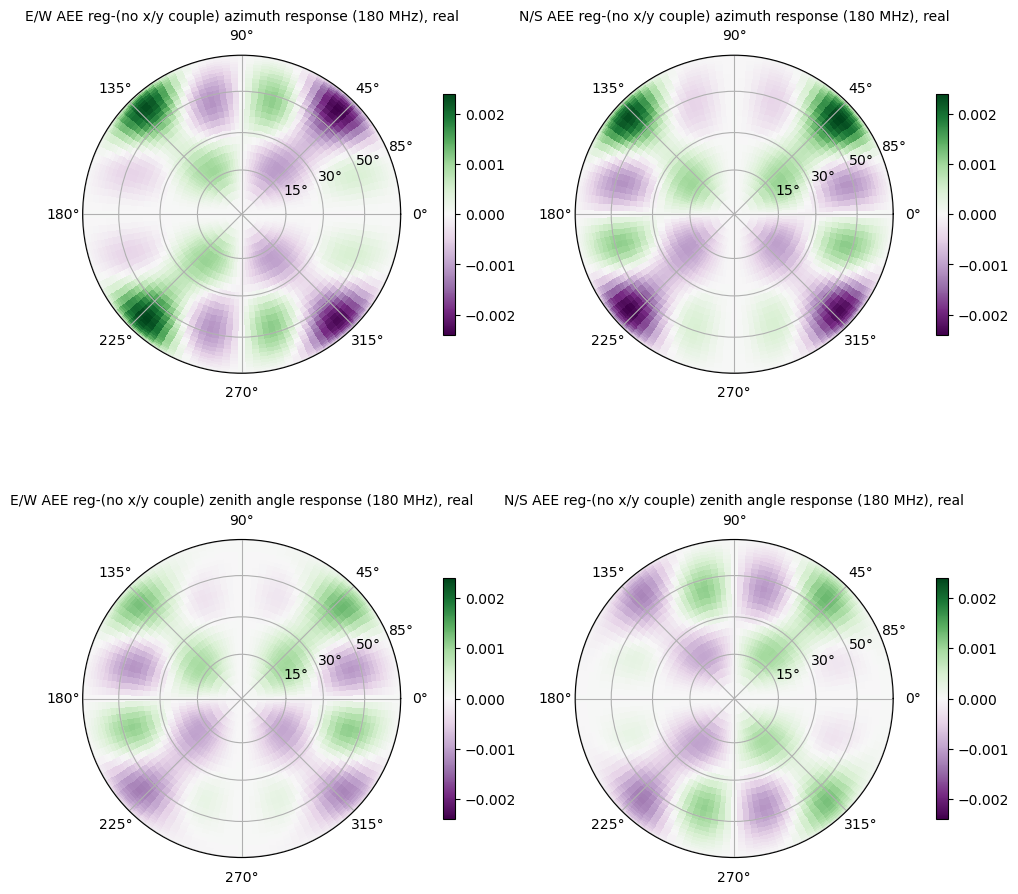

In [12]:
diff_beam = mwa_aee_beam.copy()

diff_beam.data_array = mwa_aee_beam.data_array - mwa_fhd_aee_beam.data_array

diff_beam.plot(freq_ind=41, beam_name="AEE reg-(no x/y couple)")


In [20]:
fee_at_aee_iresp, fee_at_aee_proj = fee_at_aee_grid_beam.decompose_feed_iresponse_projection()
mwa_aee_iresp, mwa_aee_proj = mwa_aee_beam.decompose_feed_iresponse_projection()
mwa_fhd_aee_iresp, mwa_fhd_aee_proj = mwa_fhd_aee_beam.decompose_feed_iresponse_projection()

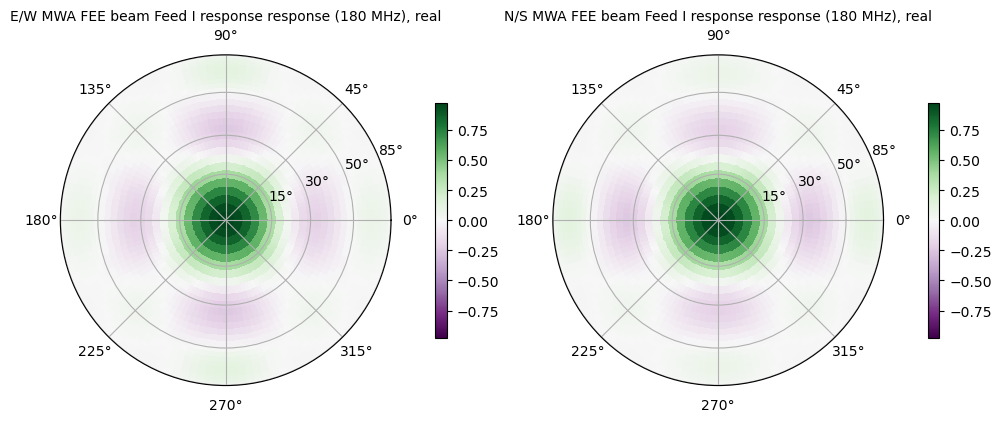

In [22]:
fee_at_aee_iresp.plot(freq_ind=0, beam_name="MWA FEE beam")

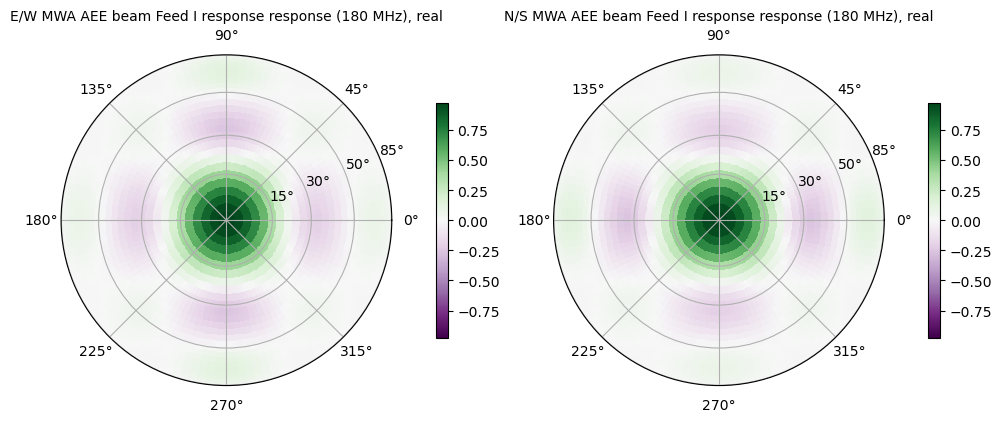

In [23]:
mwa_aee_iresp.plot(freq_ind=41, beam_name="MWA AEE beam")

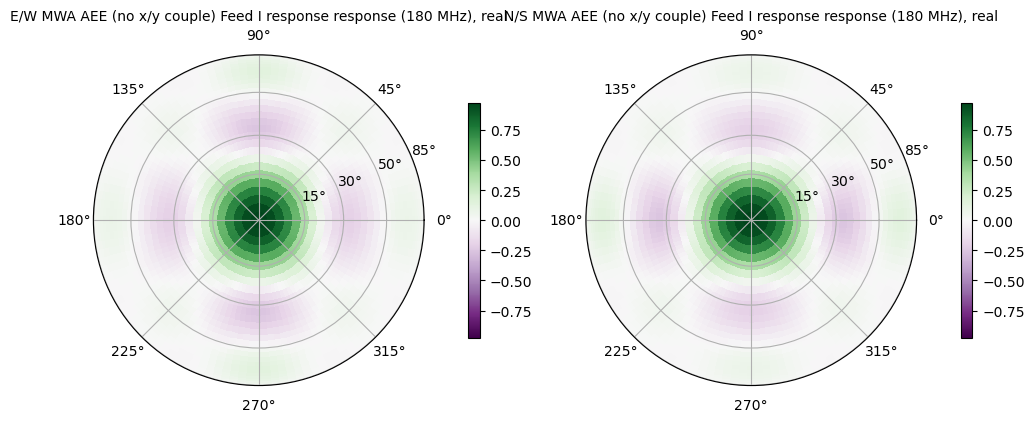

In [41]:
mwa_fhd_aee_iresp.plot(freq_ind=41, beam_name="MWA AEE (no x/y couple)")

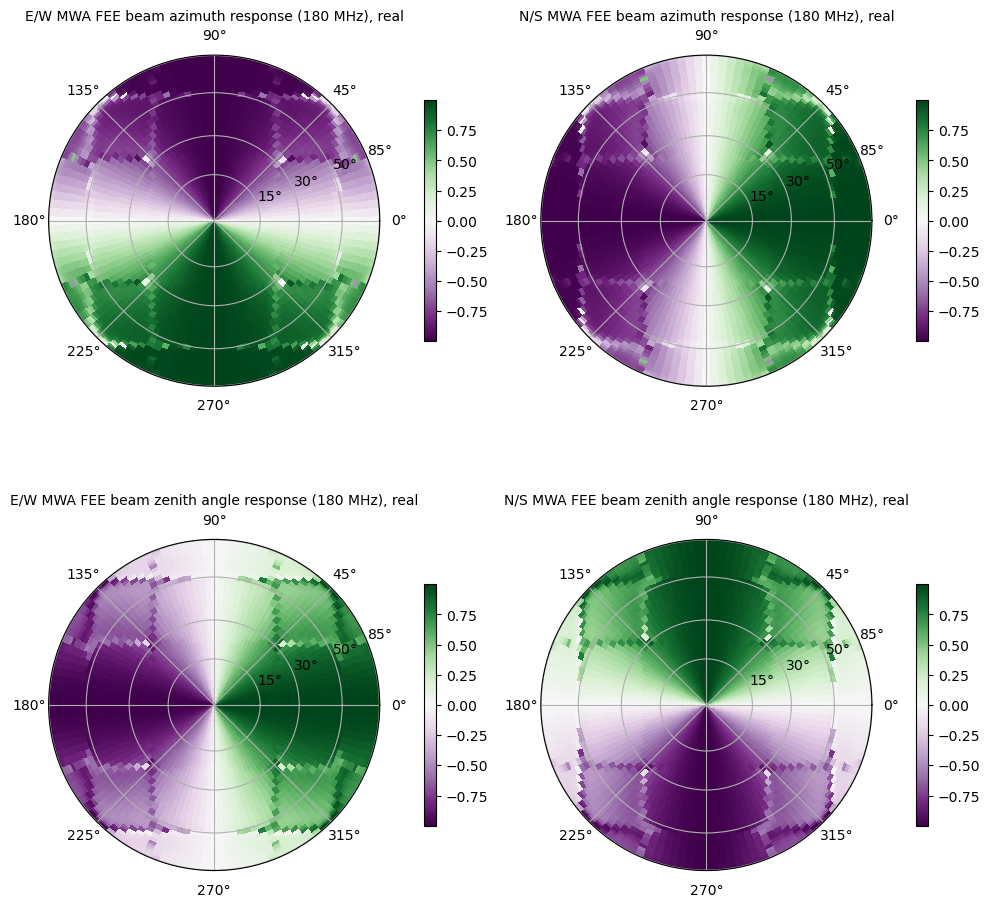

In [25]:
fee_at_aee_proj.plot(freq_ind=0, beam_name="MWA FEE beam")

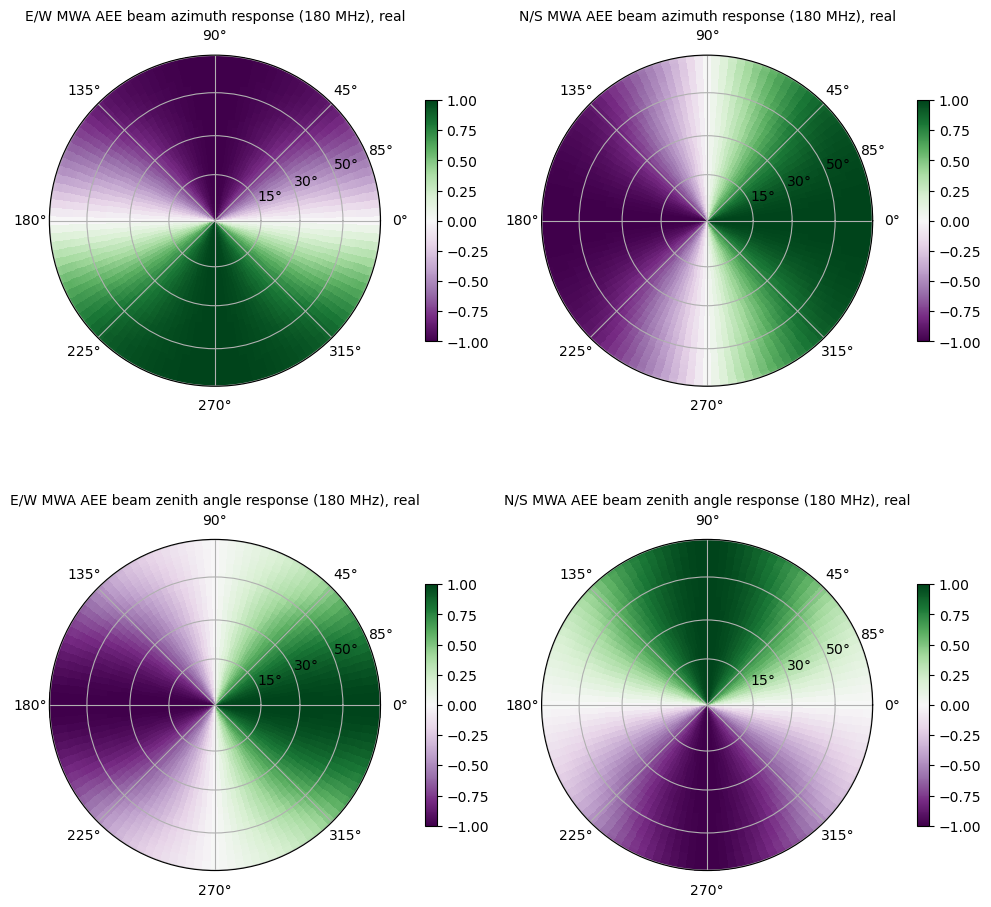

In [26]:
mwa_aee_proj.plot(freq_ind=41, beam_name="MWA AEE beam")

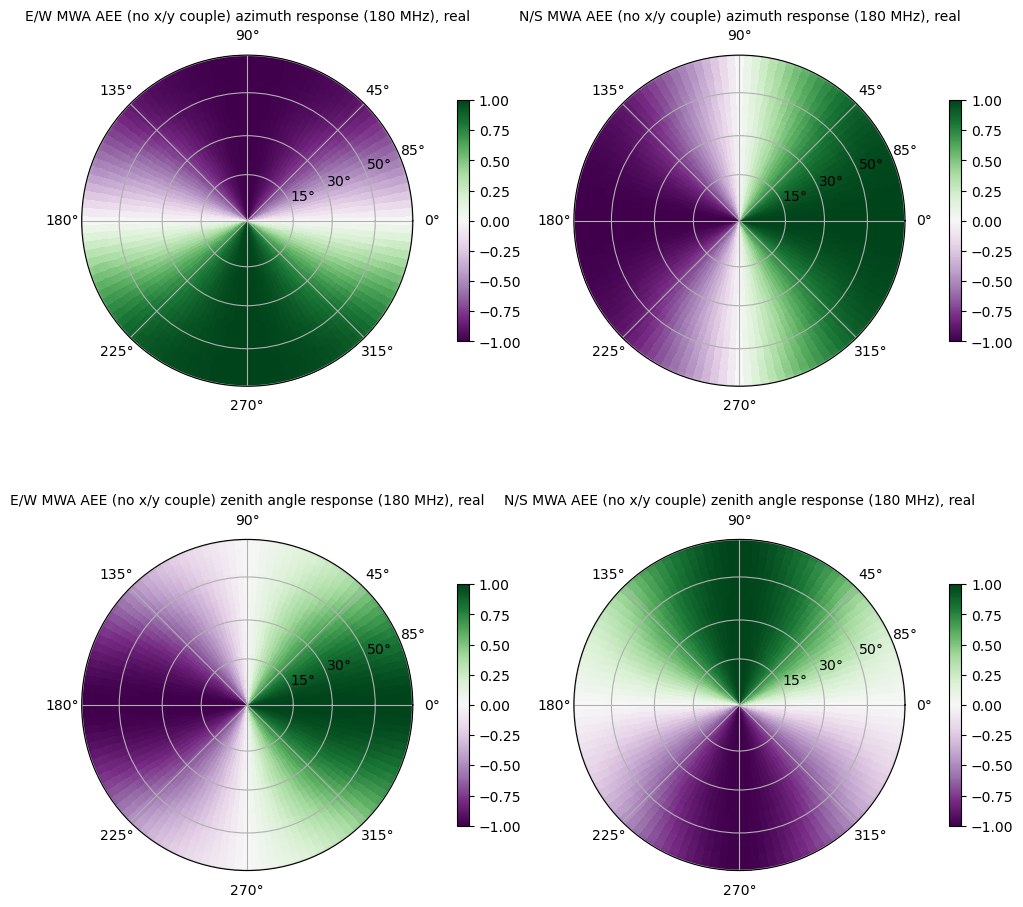

In [28]:
mwa_fhd_aee_proj.plot(freq_ind=41, beam_name="MWA AEE (no x/y couple)")

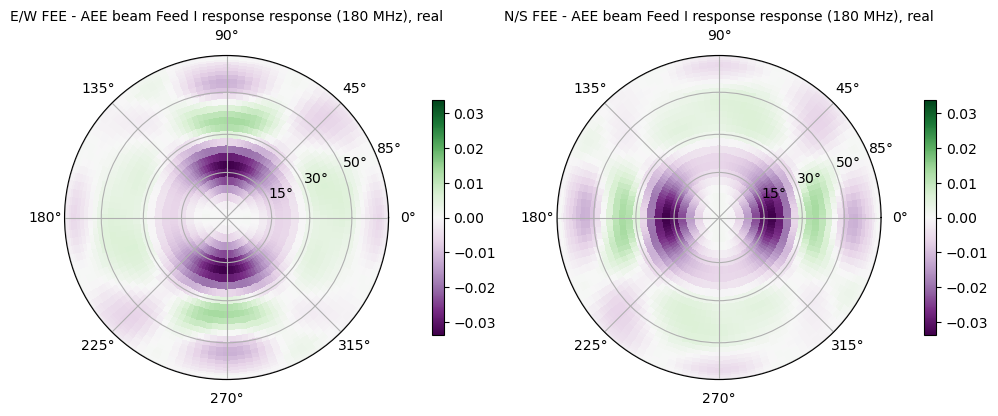

In [50]:
fee_aee_diff_iresp = fee_at_aee_iresp.copy()
mwa_aee_iresp_180 = mwa_aee_iresp.select(freq_chans=[41], inplace=False)

fee_aee_diff_iresp.data_array = fee_at_aee_iresp.data_array - mwa_aee_iresp_180.data_array

fee_aee_diff_iresp.plot(freq_ind=0, beam_name="FEE - AEE beam")

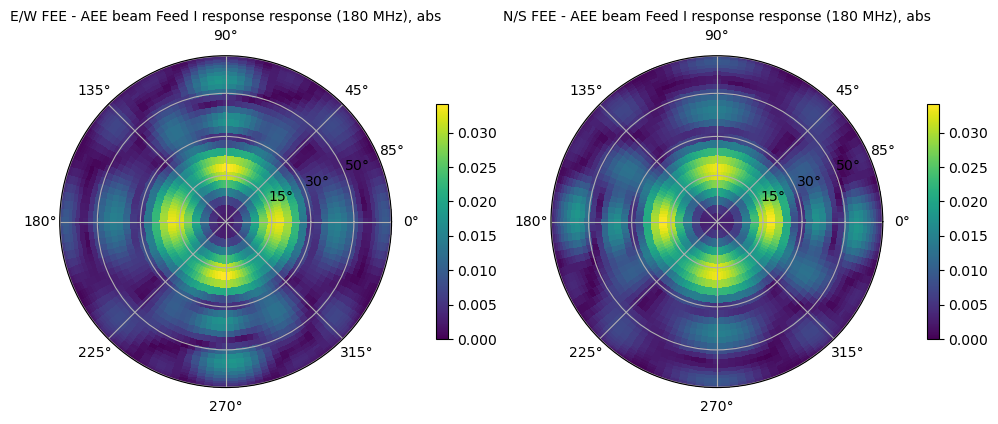

In [51]:
fee_aee_diff_iresp.plot(freq_ind=0, beam_name="FEE - AEE beam", complex_type="abs")

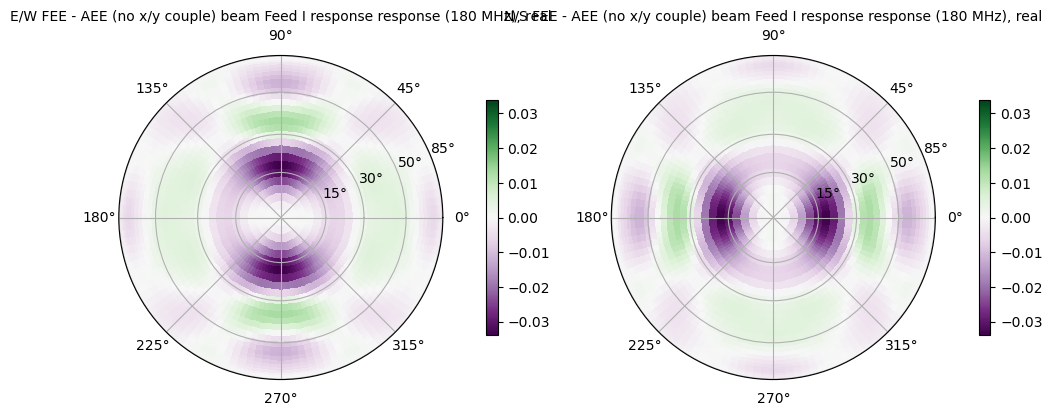

In [52]:
fee_fhd_aee_diff_iresp = fee_at_aee_iresp.copy()
mwa_fhd_aee_iresp_180 = mwa_fhd_aee_iresp.select(freq_chans=[41], inplace=False)

fee_fhd_aee_diff_iresp.data_array = fee_at_aee_iresp.data_array - mwa_fhd_aee_iresp_180.data_array

fee_fhd_aee_diff_iresp.plot(freq_ind=0, beam_name="FEE - AEE (no x/y couple) beam")

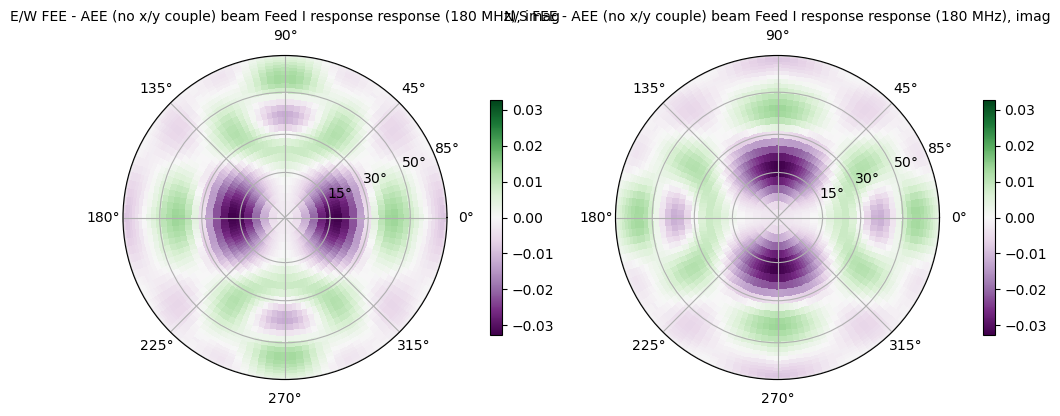

In [54]:
fee_fhd_aee_diff_iresp.plot(freq_ind=0, beam_name="FEE - AEE (no x/y couple) beam", complex_type="imag")

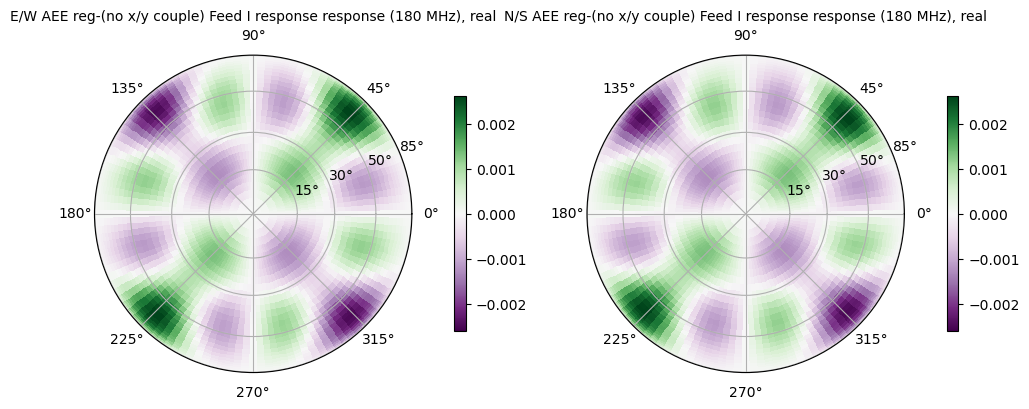

In [46]:
diff_iresp = mwa_aee_iresp.copy()

diff_iresp.data_array = mwa_aee_iresp.data_array - mwa_fhd_aee_iresp.data_array

diff_iresp.plot(freq_ind=41, beam_name="AEE reg-(no x/y couple)")

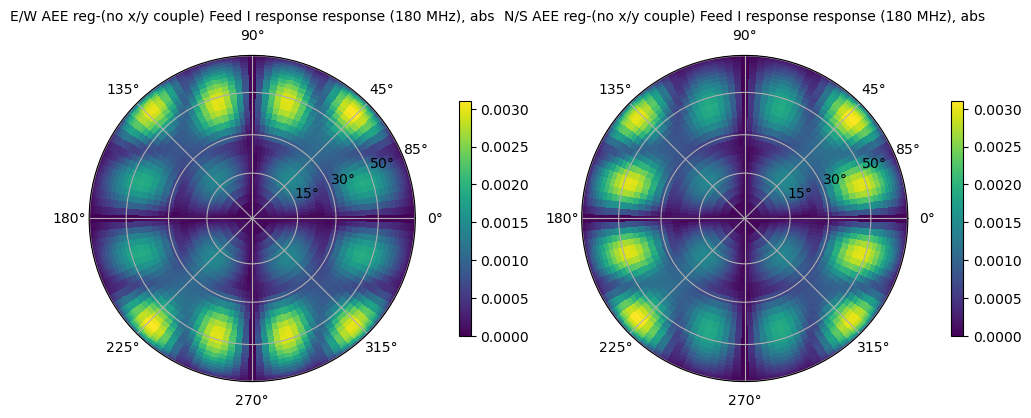

In [47]:
diff_iresp.plot(freq_ind=41, beam_name="AEE reg-(no x/y couple)", complex_type="abs")

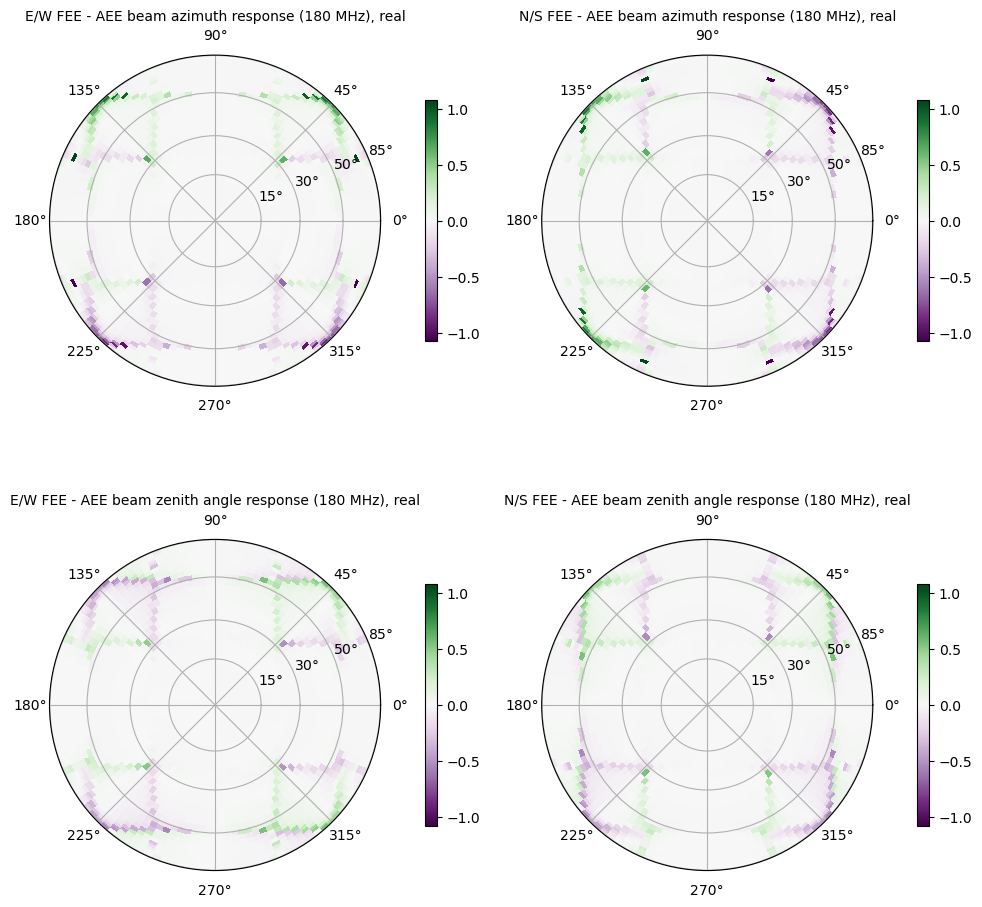

In [32]:
fee_aee_diff_proj = fee_at_aee_proj.copy()
mwa_aee_proj_180 = mwa_aee_proj.select(freq_chans=[41], inplace=False)

fee_aee_diff_proj.data_array = fee_at_aee_proj.data_array - mwa_aee_proj_180.data_array

fee_aee_diff_proj.plot(freq_ind=0, beam_name="FEE - AEE beam")

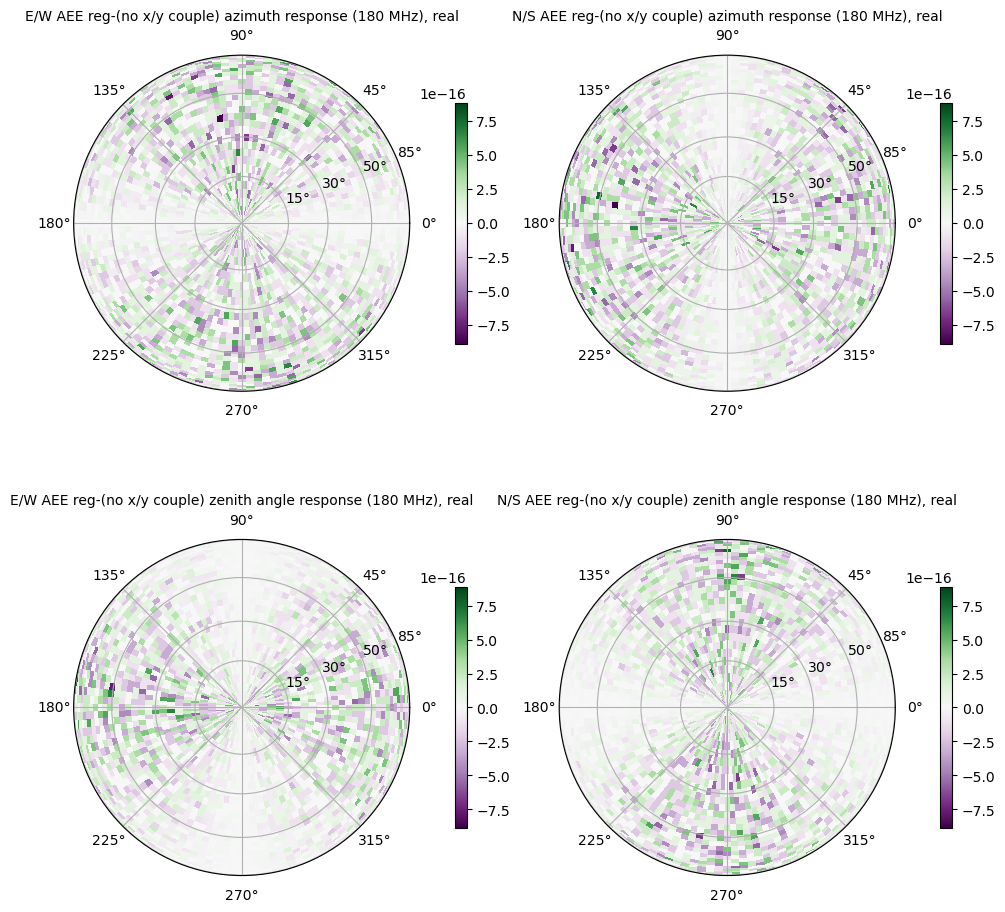

In [35]:
diff_proj = mwa_aee_proj.copy()

diff_proj.data_array = mwa_aee_proj.data_array - mwa_fhd_aee_proj.data_array

diff_proj.plot(freq_ind=41, beam_name="AEE reg-(no x/y couple)")